<a href="https://colab.research.google.com/github/chandru110/DEEP_LEARNING_LAB_1-2-3/blob/main/Neural_Network_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final Loss: 4.255582553014392e-06
Final Accuracy: 100.0

Predictions
[0. 0.] -> 3.1573863e-06 Class: 0
[0. 1.] -> 0.99999785 Class: 1
[1. 0.] -> 0.99999374 Class: 1
[1. 1.] -> 5.476343e-06 Class: 0


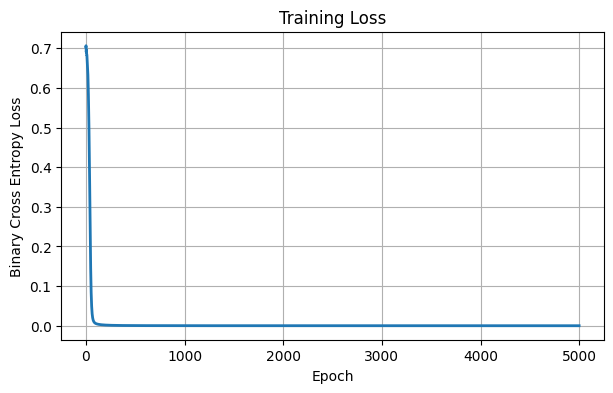

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Set random seed
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

# XOR Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

# Model (ONE hidden layer)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(
        8,
        activation='sigmoid',
        kernel_initializer='glorot_uniform'
    ),
    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X,
    y,
    epochs=5000,
    batch_size=4,
    shuffle=True,
    verbose=0
)

loss, accuracy = model.evaluate(X, y, verbose=0)

print("Final Loss:", loss)
print("Final Accuracy:", accuracy * 100)

pred = model.predict(X, verbose=0)

print("\nPredictions")
for i in range(4):
    print(
        X[i],
        "->",
        pred[i][0],
        "Class:",
        int(pred[i][0] > 0.5)
    )

# Plot Training Loss
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], linewidth=2)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.grid(True)
plt.show()

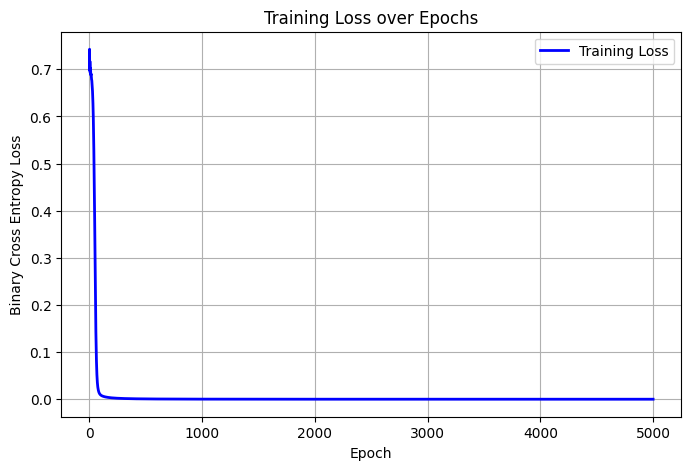

In [ ]:
import matplotlib.pyplot as plt

# Plot Training Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], color='blue', linewidth=2, label='Training Loss')

plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.legend()
plt.grid(True)

plt.show()